<a href="https://www.arduino.cc/"><img src="https://raw.githubusercontent.com/sandeepmistry/aimldevfest-workshop-2019/master/images/Arduino_logo_R_highquality.png" width=200/></a>
# Tiny ML on Arduino
## Gesture recognition tutorial
 * Sandeep Mistry - Arduino
 * Don Coleman - Chariot Solutions


https://github.com/arduino/ArduinoTensorFlowLiteTutorials/

In [32]:
on_drive = False 
if on_drive:
    base_path = ''
    output_path = ''
else:
    base_path = 'data-gesures/a-'
    output_path = 'scratch/a-'

## Setup Python Environment

The next cell sets up the dependencies in required for the notebook, run it.

In [33]:
# Setup environment
!pip install pandas numpy matplotlib seaborn
!pip install tensorflow

1525.78s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


1531.27s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Upload Data

1. Open the panel on the left side of Colab by clicking on the __>__
1. Select the files tab
1. Drag all files from your computer to the tab to upload them into colab.

# Graph Data (optional)

We'll graph the input files on two separate graphs, acceleration and gyroscope, as each data set has different units and scale.

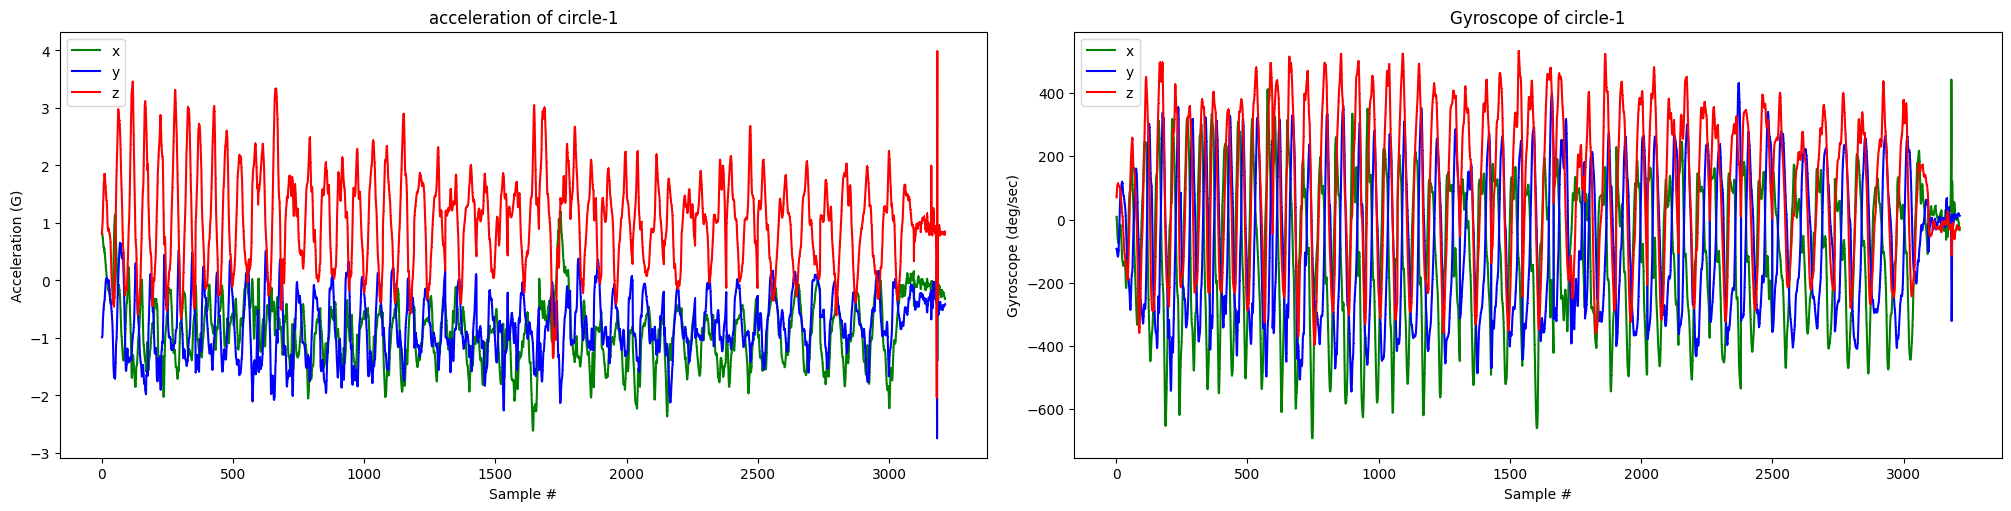

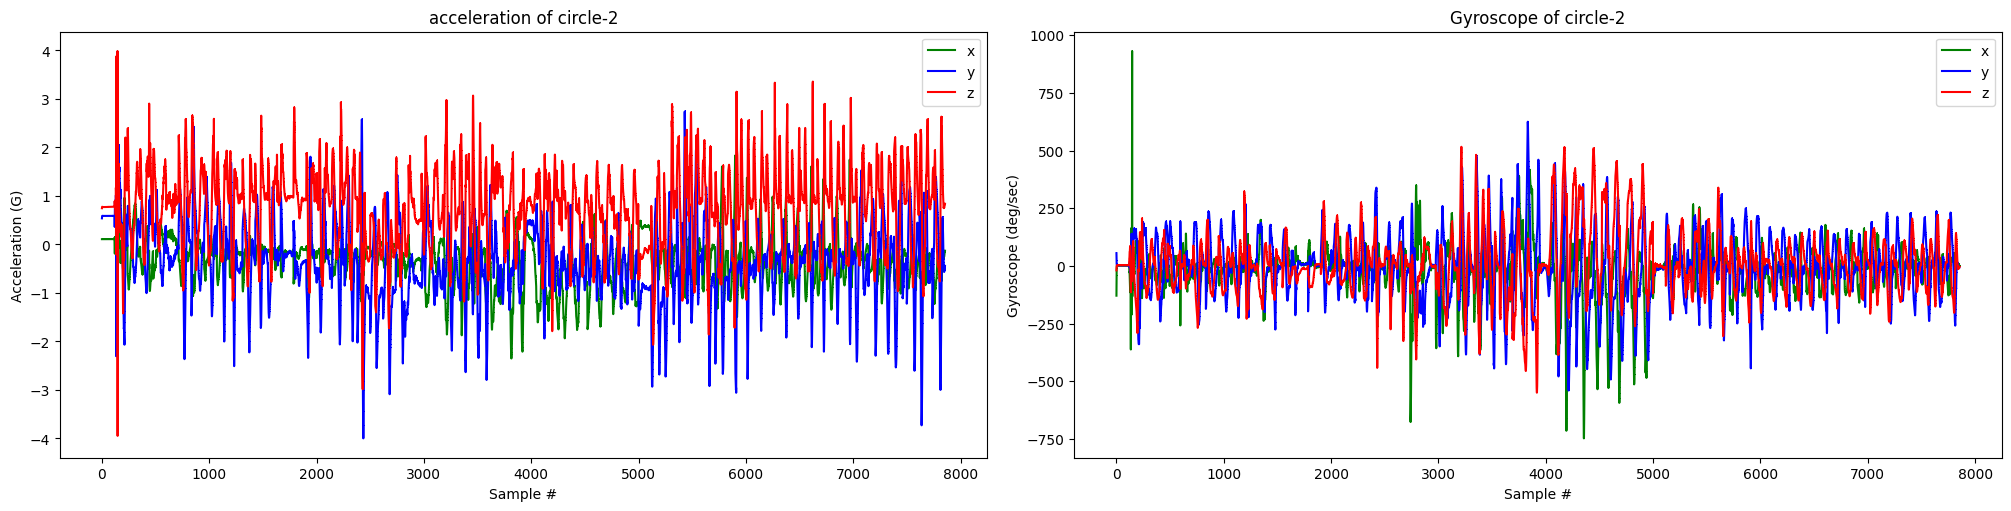

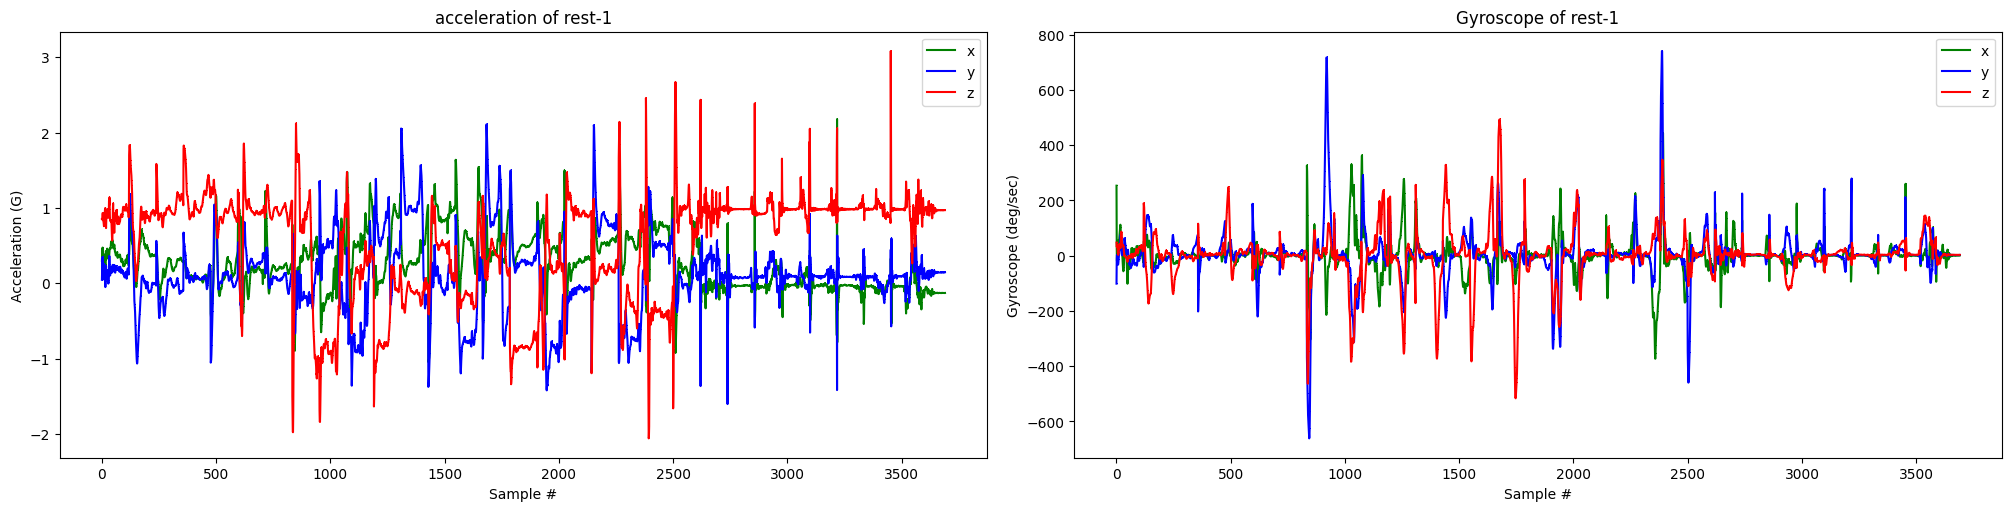

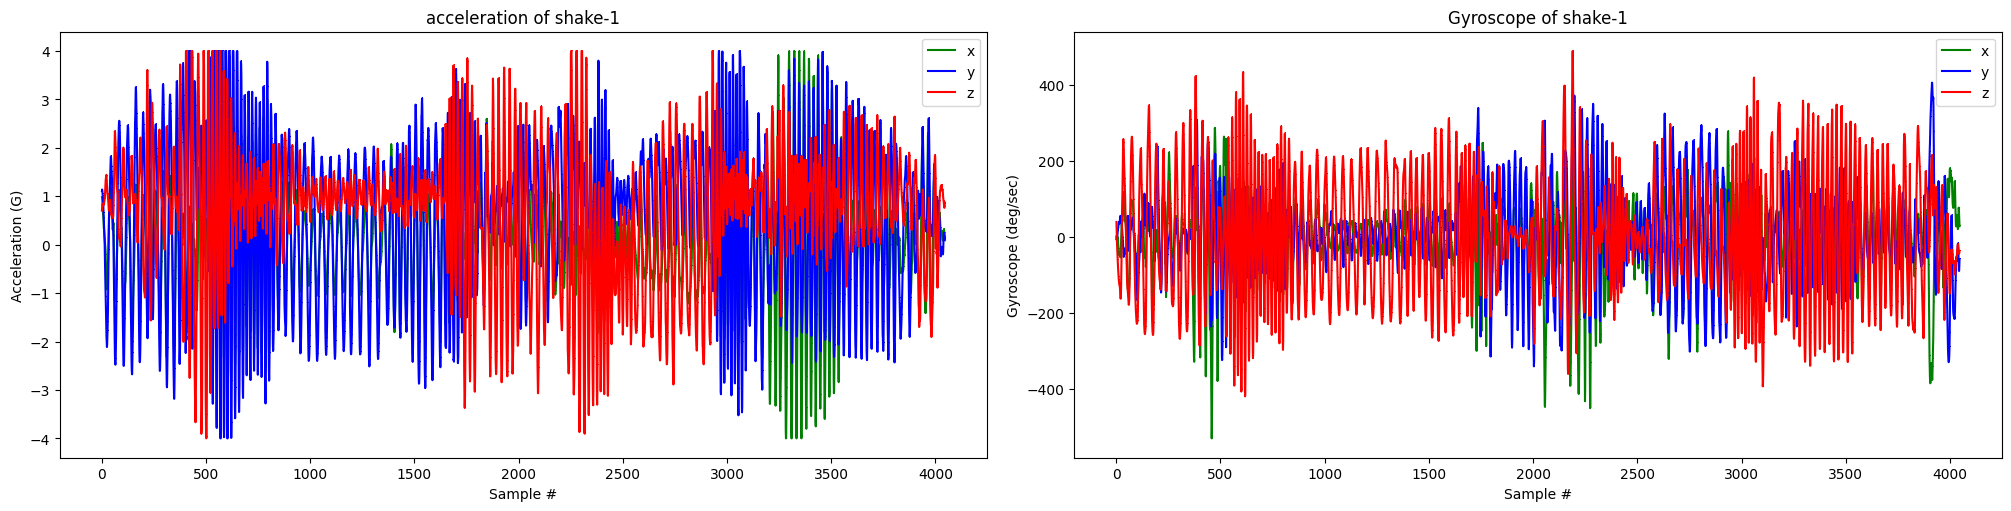

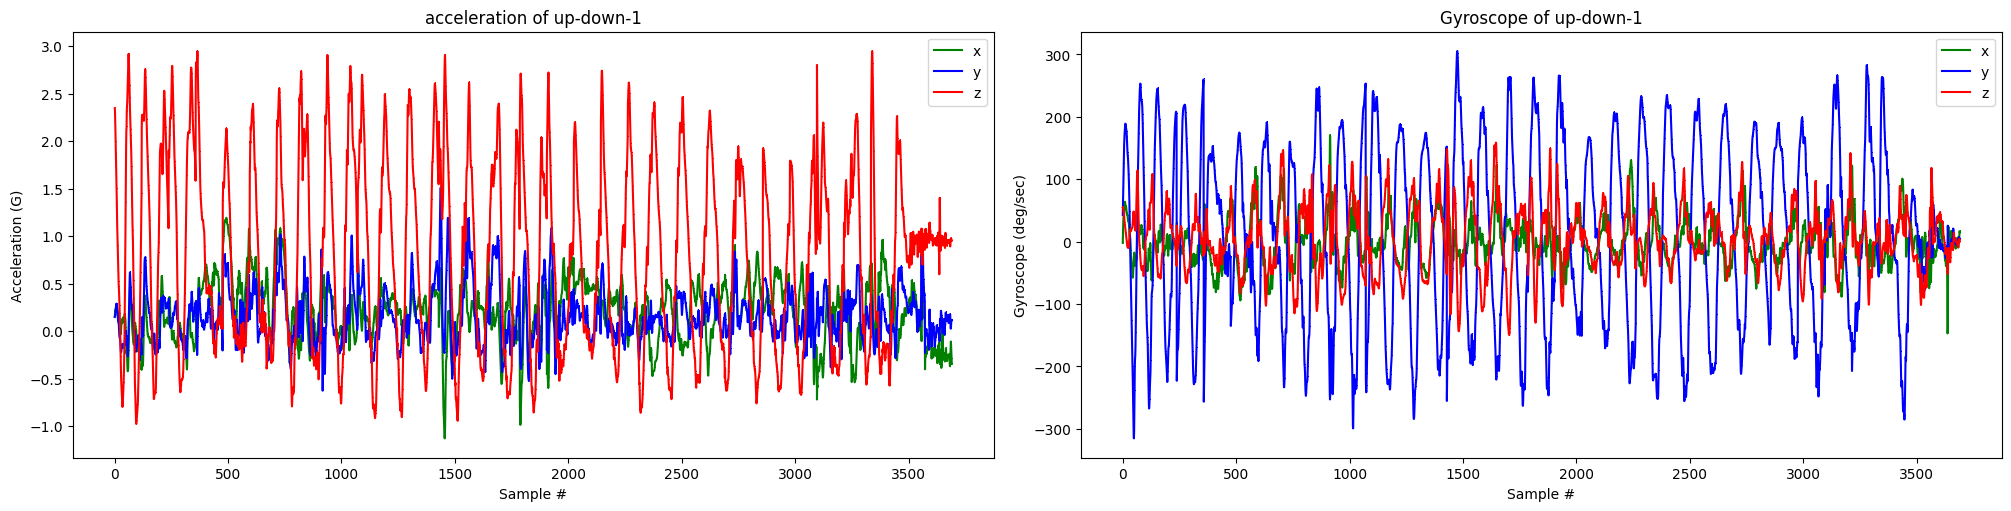

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# the list of gestures that data is available for
GESTURES = [
    "circle-1",
    "circle-2",
    "rest-1",
    "shake-1",
    "up-down-1",
    # "punch",
    # "flex",
]
NUM_GESTURES = len(GESTURES)


for filename in GESTURES :
  name = base_path + filename + ".csv"

  df = pd.read_csv(name)

  index = range(1, len(df['aX']) + 1)
  
  if on_drive:
    fig, axs = plt.subplots(1, 2, layout='constrained', figsize=(20, 10))
  else:
    fig, axs = plt.subplots(1, 2, layout='constrained', figsize=(20, 5))
    
  
  axs[0].plot(index, df['aX'], 'g', label='x', linestyle='solid', marker=',')
  axs[0].plot(index, df['aY'], 'b', label='y', linestyle='solid', marker=',')
  axs[0].plot(index, df['aZ'], 'r', label='z', linestyle='solid', marker=',')
  name = "acceleration of " + filename
  axs[0].set_title(name)
  axs[0].set_xlabel("Sample #")
  axs[0].set_ylabel("Acceleration (G)")
  axs[0].legend()
  axs[1].plot(index, df['gX'], 'g', label='x', linestyle='solid', marker=',')
  axs[1].plot(index, df['gY'], 'b', label='y', linestyle='solid', marker=',')
  axs[1].plot(index, df['gZ'], 'r', label='z', linestyle='solid', marker=',')
  name = "Gyroscope of " + filename
  axs[1].set_title(name)
  axs[1].set_xlabel("Sample #")
  axs[1].set_ylabel("Gyroscope (deg/sec)")
  axs[1].legend()

  plt.show()


# Train Neural Network





## Parse and prepare the data

The next cell parses the csv files and transforms them to a format that will be used to train the fully connected neural network.

Update the `GESTURES` list with the gesture data you've collected in `.csv` format.


In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print(f"TensorFlow version = {tf.__version__}\n")

# Set a fixed random seed value, for reproducibility, this will allow us to get
# the same random numbers each time the notebook is run
SEED = int(pd.Timestamp.now().timestamp())
np.random.seed(SEED)
tf.random.set_seed(SEED)

SAMPLES_PER_GESTURE = 119

# create a one-hot encoded matrix that is used in the output
ONE_HOT_ENCODED_GESTURES = np.eye(NUM_GESTURES)

inputs = []
outputs = []

# read each csv file and push an input and output"/content/"
for gesture_index in range(NUM_GESTURES):
  gesture = GESTURES[gesture_index]
  print(f"Processing index {gesture_index} for gesture '{gesture}'.")

  output = ONE_HOT_ENCODED_GESTURES[gesture_index]

  df = pd.read_csv(base_path + gesture + ".csv")

  # calculate the number of gesture recordings in the file
  num_recordings = int(df.shape[0] / SAMPLES_PER_GESTURE)

  print(f"\tThere are {num_recordings} recordings of the {gesture} gesture.")

  for i in range(num_recordings):
    tensor = []
    for j in range(SAMPLES_PER_GESTURE):
      index = i * SAMPLES_PER_GESTURE + j
      # normalize the input data, between 0 to 1:
      # - acceleration is between: -4 to +4
      # - gyroscope is between: -2000 to +2000
      tensor += [
          (df['aX'][index] + 4) / 8,
          (df['aY'][index] + 4) / 8,
          (df['aZ'][index] + 4) / 8,
          (df['gX'][index] + 2000) / 4000,
          (df['gY'][index] + 2000) / 4000,
          (df['gZ'][index] + 2000) / 4000
      ]

    inputs.append(tensor)
    outputs.append(output)

# convert the list to numpy array
inputs = np.array(inputs)
outputs = np.array(outputs)

print("Input shape:", inputs.shape)
print("Output shape:", outputs.shape)

print("Data set parsing and preparation complete.")

TensorFlow version = 2.21.0

Processing index 0 for gesture 'circle-1'.
	There are 27 recordings of the circle-1 gesture.
Processing index 1 for gesture 'circle-2'.
	There are 66 recordings of the circle-2 gesture.
Processing index 2 for gesture 'rest-1'.
	There are 31 recordings of the rest-1 gesture.
Processing index 3 for gesture 'shake-1'.
	There are 34 recordings of the shake-1 gesture.
Processing index 4 for gesture 'up-down-1'.
	There are 31 recordings of the up-down-1 gesture.
Input shape: (189, 714)
Output shape: (189, 5)
Data set parsing and preparation complete.


## Randomize and split the input and output pairs for training

Randomly split input and output pairs into sets of data: 60% for training, 20% for validation, and 20% for testing.

  - the training set is used to train the model
  - the validation set is used to measure how well the model is performing during training
  - the testing set is used to test the model after training

In [36]:
# Randomize the order of the inputs, so they can be evenly distributed for training, testing, and validation
# https://stackoverflow.com/a/37710486/2020087
num_inputs = len(inputs)
randomize = np.arange(num_inputs)
np.random.shuffle(randomize)

# Swap the consecutive indexes (0, 1, 2, etc) with the randomized indexes
inputs = inputs[randomize]
outputs = outputs[randomize]

# Split the recordings (group of samples) into three sets: training, testing and validation
TRAIN_SPLIT = int(0.6 * num_inputs)
TEST_SPLIT = int(0.2 * num_inputs + TRAIN_SPLIT)

inputs_train, inputs_test, inputs_validate = np.split(inputs, [TRAIN_SPLIT, TEST_SPLIT])
outputs_train, outputs_test, outputs_validate = np.split(outputs, [TRAIN_SPLIT, TEST_SPLIT])

print("Data set randomization and splitting complete.")

Data set randomization and splitting complete.


## Build & Train the Model

Build and train a [TensorFlow](https://www.tensorflow.org) model using the high-level [Keras](https://www.tensorflow.org/guide/keras) API.

In [37]:
# build the model and train it
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(50, activation='relu',input_shape=(inputs.shape[1],))) # relu is used for performance
model.add(tf.keras.layers.Dense(30, activation='relu'))
model.add(tf.keras.layers.Dropout(0.35))
model.add(tf.keras.layers.Dense(15, activation='relu'))
model.add(tf.keras.layers.Dense(15, activation='relu'))
model.add(tf.keras.layers.Dense(NUM_GESTURES, activation='softmax')) # softmax is used, because we only expect one gesture to occur per input

# Loss : we use categorical_crossentropy adapted to classification with more than 2 classes
# Metric : accuracy (for the same reason)
# Optimizer : more modern, Adam (Adaptative Moment Estmiation), each weight has his own learning rate adaptative
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#For the batch_size we changed it by 8 because there is too much noise at 1
#so 8 seems to be a good compromise to have a fast convergence.
history = model.fit(inputs_train, outputs_train, epochs=600, batch_size=8, validation_data=(inputs_validate, outputs_validate))

Epoch 1/600


/home/alanmasu/Documenti/Low-Power_IoT/EMBEDDED-GESTURE-RECO/.venv/lib64/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2743 - loss: 1.6245 - val_accuracy: 0.3846 - val_loss: 1.5364
Epoch 2/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3186 - loss: 1.5707 - val_accuracy: 0.3846 - val_loss: 1.5595
Epoch 3/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3009 - loss: 1.5808 - val_accuracy: 0.3846 - val_loss: 1.5582
Epoch 4/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3363 - loss: 1.5674 - val_accuracy: 0.3846 - val_loss: 1.5350
Epoch 5/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3451 - loss: 1.5707 - val_accuracy: 0.3846 - val_loss: 1.5484
Epoch 6/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3451 - loss: 1.5502 - val_accuracy: 0.3846 - val_loss: 1.5524
Epoch 7/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3451 - loss: 1.5528 - val_accuracy: 0.3846 - val_loss: 1.5340
Epoch 8/600
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3451 - loss: 1.5659 - val_accuracy: 0.3846 - val_loss: 1.

## Verify

Graph the models performance vs validation.


### Graph the loss

Graph the loss to see when the model stops improving.

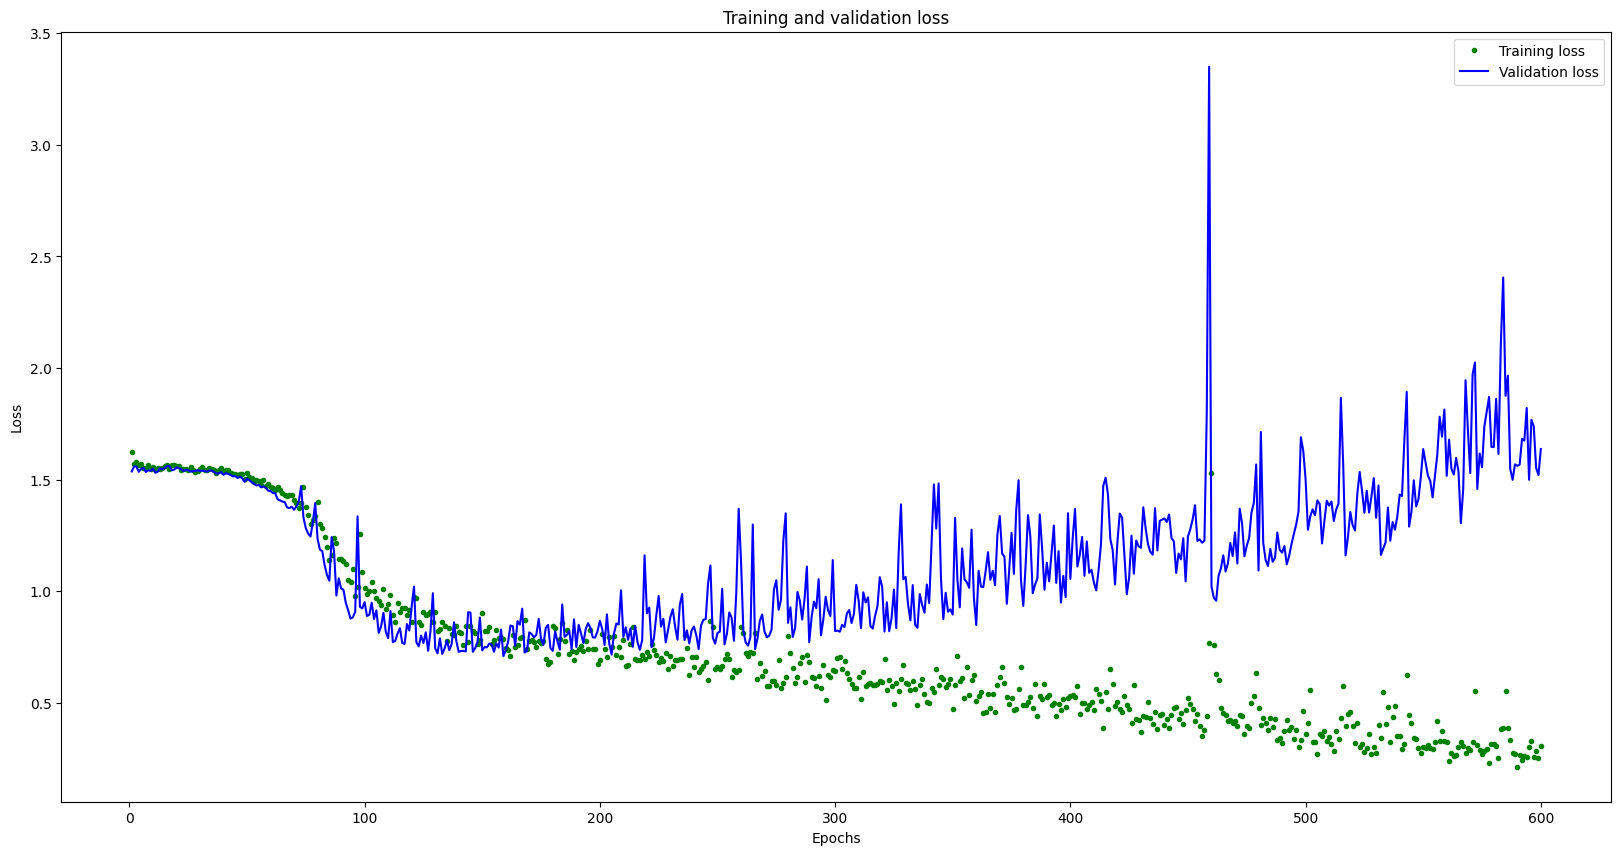

[20.0, 10.0]


In [38]:
# increase the size of the graphs. The default size is (6,4).
plt.rcParams["figure.figsize"] = (20,10)

# graph the loss, the model above is configure to use "mean squared error" as the loss function
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'g.', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(plt.rcParams["figure.figsize"])

### Graph the loss again, skipping a bit of the start

We'll graph the same data as the previous code cell, but start at index 100 so we can further zoom in once the model starts to converge.

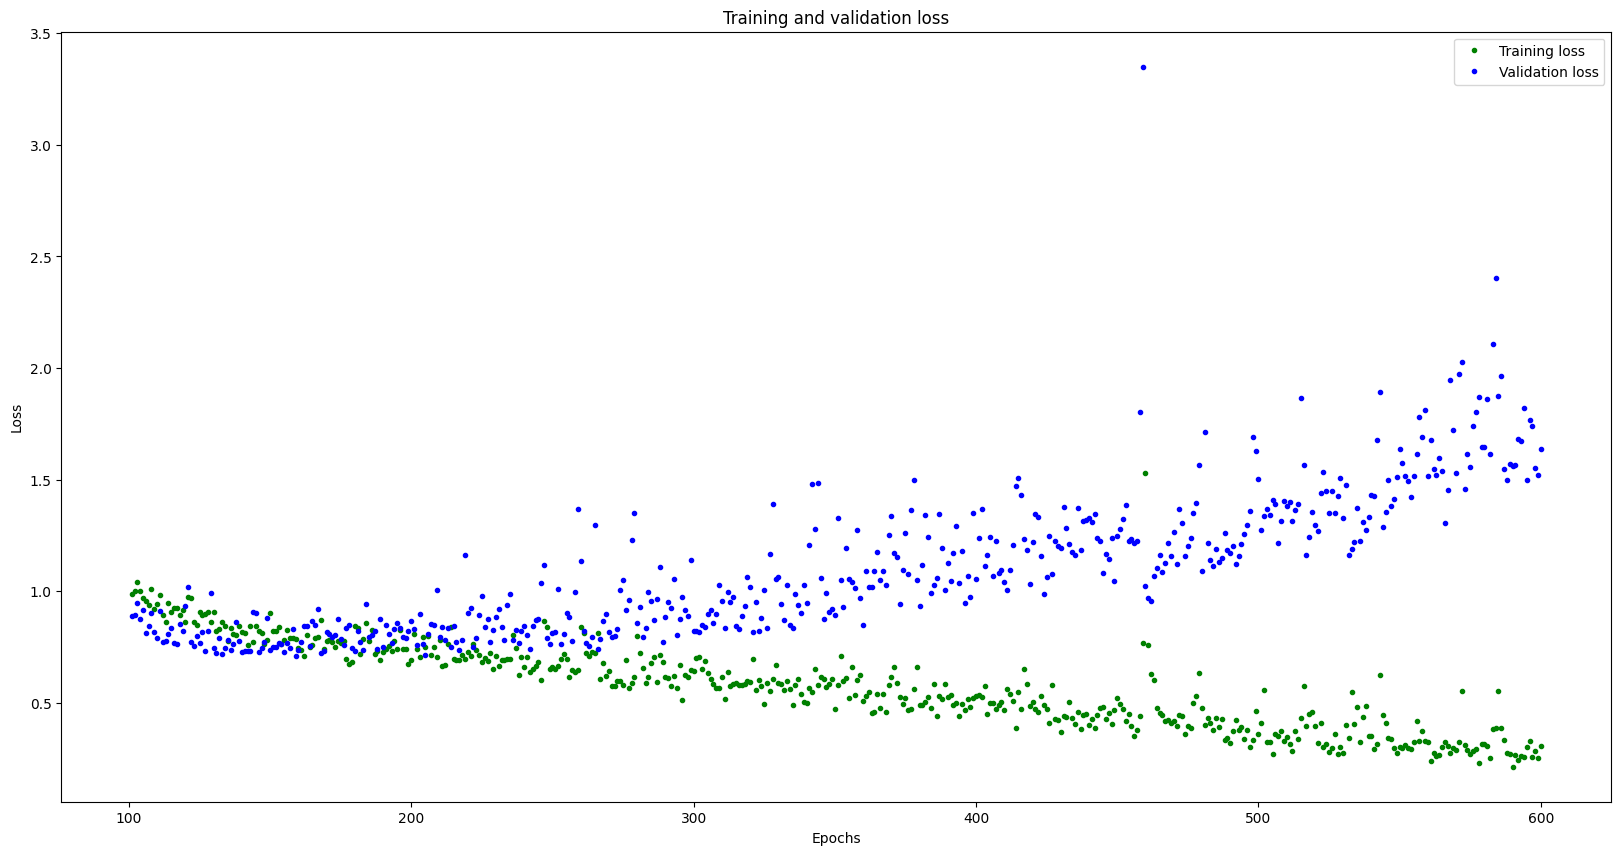

In [39]:
# graph the loss again skipping a bit of the start
SKIP = 100
plt.plot(epochs[SKIP:], loss[SKIP:], 'g.', label='Training loss')
plt.plot(epochs[SKIP:], val_loss[SKIP:], 'b.', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Run with Test Data
Put our test data into the model and plot the predictions


Test accuracy: 0.7297


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/stepWARNING:tensorflow:6 out of the last 10 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7f7604e01080> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7297 - loss: 0.9546
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


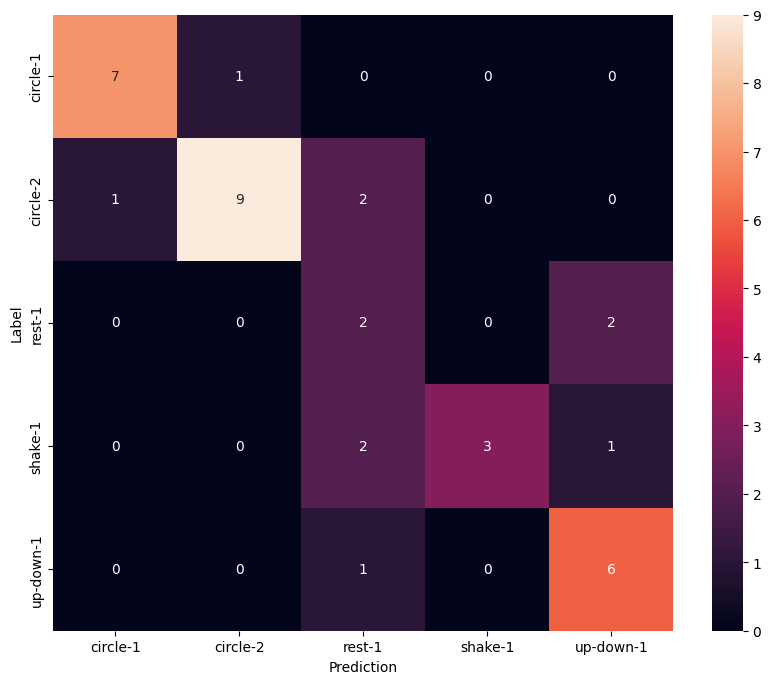

predicted classes =
 [1 1 0 0 1 0 4 3 1 3 1 2 4 2 2 1 0 4 1 4 1 2 0 4 2 1 0 0 0 3 4 4 2 1 4 4 2]
actual classes =
 [1 1 0 0 1 0 4 3 1 3 1 3 4 1 4 1 0 2 0 4 1 3 1 4 2 1 0 0 0 3 2 4 2 1 4 3 1]


In [40]:
# Evaluate on test set
import seaborn as sns
test_loss, test_acc = model.evaluate(inputs_test, outputs_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# use the model to predict the test inputs
predictions = model.predict(inputs_test)

# Convert to class indices
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(outputs_test, axis=1)

# # use the model to predict the test inputs
model.evaluate(inputs_test, outputs_test)
predictions = model.predict(inputs_test)

# # print the predictions and the expected


# confusion matrix
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=GESTURES,
            yticklabels=GESTURES,
            annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

# print the predictions and the expected ouputs
# print("predictions =\n", np.round(predictions, decimals=3))
# print("actual =\n", outputs_test)
print("predicted classes =\n", y_pred)
print("actual classes =\n", y_true)

# Convert the Trained Model to Tensor Flow Lite

The next cell converts the model to TFlite format. The size in bytes of the model is also printed out.

In [41]:
# Check if the output directory exists, if not create it
import os
if not os.path.exists(output_path):
    os.makedirs(output_path)

# Convert the model to the TensorFlow Lite format without quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the model to disk
open(output_path + "gesture_model.tflite", "wb").write(tflite_model)

basic_model_size = os.path.getsize(output_path + "gesture_model.tflite")
print("Model is %d bytes" % basic_model_size)

INFO:tensorflow:Assets written to: /tmp/tmp2cahbnv9/assets


INFO:tensorflow:Assets written to: /tmp/tmp2cahbnv9/assets


Saved artifact at '/tmp/tmp2cahbnv9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 714), dtype=tf.float32, name='keras_tensor_44')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  140142243898640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140142243900176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140141477540880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140141477540112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140141477539344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140141477537616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140141477541072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140141477537232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140141477539536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140141477536656: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model is 155436 bytes

W0000 00:00:1774891852.081800  116324 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1774891852.081810  116324 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1774891852.081909  116324 reader.cc:83] Reading SavedModel from: /tmp/tmp2cahbnv9
I0000 00:00:1774891852.082296  116324 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1774891852.082300  116324 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp2cahbnv9
I0000 00:00:1774891852.085734  116324 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1774891852.107412  116324 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp2cahbnv9
I0000 00:00:1774891852.112900  116324 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 30998 microseconds.


## Encode the Model in an Arduino Header File

The next cell creates a constant byte array that contains the TFlite model. Import it as a tab with the sketch below.

In [42]:
def convert_tflite_to_header(tflite_path, header_path):
  # Reading the TFLite model file as binary data
  with open(tflite_path, 'rb') as f:
    data = f.read()

  with open(header_path, 'w') as f:
    # Write the header guard and the declaration of the model array
    f.write("const unsigned char model[] = {\n")
    
    # Converting each byte to hexadecimal format (0x00)
    # We put 12 bytes per line to keep the file readable
    hex_lines = []
    for i in range(0, len(data), 12):
      chunk = data[i:i + 12]
      hex_chunk = ", ".join([f"0x{b:02x}" for b in chunk])
      hex_lines.append("  " + hex_chunk)
    
    # Join the lines with a comma and newline
    f.write(",\n".join(hex_lines))
    
    # Close the array
    f.write("\n};\n")

# Conversion
convert_tflite_to_header(output_path + "gesture_model.tflite", output_path + "model.h")

import os
model_h_size = os.path.getsize(output_path + "model.h")
print(f"Header file, model.h, is {model_h_size:,} bytes.")
print("\nOpen the side panel (refresh if needed). Double click model.h to download the file.")

Header file, model.h, is 958,556 bytes.

Open the side panel (refresh if needed). Double click model.h to download the file.


## Convert the test dataset to a C header file
The next cell creates a constant byte array that contains the test dataset.

In [43]:
# Export the test dataset to a C header file
def convert_test_dataset_to_header(inputs, outputs, header_path):
  with open(header_path, 'w') as f:
    f.write("#ifndef __TEST_DATA_H__\n")
    f.write("#define __TEST_DATA_H__\n\n")
    f.write("#include <stdint.h>\n\n")
    f.write(f"const uint16_t num_samples = {len(inputs)};\n")
    f.write(f"const uint16_t num_features = {inputs.shape[1]};\n")
    f.write(f"const uint16_t num_classes = {outputs.shape[1]};\n\n")
    
    # Write the input data
    f.write("const float test_inputs[][num_features] = {\n")
    for i in range(len(inputs)):
        input_line = ", ".join([f"{x:.6f}f" for x in inputs[i]])
        f.write(f"  {{{input_line}}},\n")
    f.write("};\n\n")
    
    # Write the output data
    f.write("const uint8_t test_outputs[][num_classes] = {\n")
    for i in range(len(outputs)):
        output_line = ", ".join([str(int(x)) for x in outputs[i]])
        f.write(f"  {{{output_line}}},\n")
    f.write("};\n")
    f.write("\n#endif // __TEST_DATA_H__\n")
    
# Conversion
convert_test_dataset_to_header(inputs_test, outputs_test, output_path + "test_data.h")